# Campus Route Planner: From Yachay Tech to Your Home
### Informed search with A* — custom costs with NetworkX and OSMnx

**Goal:** build a route planner that finds the best path between the university and your home, using the **A\*** algorithm on a real street graph.

**Why A\* and not BFS/DFS?** BFS or DFS (like in a maze) find *a* valid path. A* finds the **lowest-cost** path, guided by a heuristic — and in Part 6 you will define for yourself what "lowest cost" means (it isn't always the shortest distance).

**Estimated duration: ~2 hours**

| Part | What you do | Time | Type |
|---|---|---|---|
| 1 | Download the street graph | 10 min | Given |
| 2 | Locate your university and your home | 10 min | You fill in data |
| 3 | Baseline route with NetworkX (Dijkstra) | 10 min | Given |
| 4 | **Implement A\* with heapq** | 40 min | **You complete the code** |
| 5 | Validate your result | 10 min | Given |
| 6 | **Design your own route cost** | 25 min | **You complete the code** |
| 7 | Compare and visualize | 10 min | Given |
| — | Prepare a 5-minute presentation | 15 min | Everyone prepares |

**5-minute presentation.** A few students will be picked at random to present, but **everyone submits the notebook** — your grade does not depend on whether you get picked. Structure your 5 minutes like this:

1. **(1 min) Show your map** — the Part 7 plot: blue route vs. your red route.
2. **(1.5 min) Walk through your A\*** — what does the frontier hold, what is `g(n)` vs `h(n)`, and how do you know it works (Part 5's check against Dijkstra)?
3. **(2 min) Defend your custom cost** — what criterion did you choose in `PENALTY_BY_ROAD_TYPE`, why those numbers, and did the resulting route make sense given the trade-off?
4. **(30 sec) One thing you'd improve** — e.g., a better heuristic, a different cost signal, an edge case your code doesn't handle.

**Submission:** upload the full notebook, already run (with outputs visible). Graded PASS / FAIL on: (a) your A* works and matches the baseline route when using the default cost, (b) your custom cost has a clear, defensible criterion, (c) you can explain it if asked.


In [1]:
# Run this cell first.
# If you're using Google Colab, you don't need to install anything else: just run this.
!pip install osmnx networkx matplotlib --quiet

import heapq
import random

import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox

ox.settings.log_console = False
ox.settings.use_cache = True

print("Libraries ready.")

Libraries ready.


/Users/eugenio/Documents/ArtificialIntelligence/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Part 1 — Download the street graph

We'll download the real street network of Urcuquí from OpenStreetMap. If you want your own map, you can change `PLACE` to your own canton or city (optional).

If there's no internet at the moment, the cell automatically falls back to a **backup graph** (a synthetic grid with the same structure) so you can keep working without interruption.

Real graph downloaded: 620 nodes, 1626 edges.


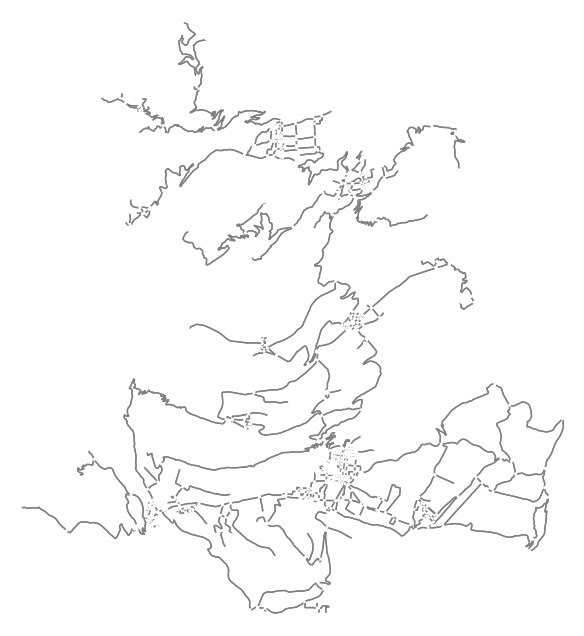

In [2]:
PLACE = "Urcuquí, Ecuador"  # change this to your own canton/city if you want your own map


def backup_graph(rows=8, cols=8, lat0=0.4046, lon0=-78.1749, spacing=0.0012):
    '''
    Synthetic backup grid (for when there's no internet).
    It isn't a real map, but it has the same structure as an OSMnx graph
    (nodes with 'y'/'x', edges with 'length' and 'highway') so the rest of
    the notebook works exactly the same way.
    '''
    random.seed(7)
    H = nx.MultiDiGraph()
    H.graph["crs"] = "epsg:4326"
    road_types = ["residential", "residential", "residential", "primary", "footway"]
    for i in range(rows):
        for j in range(cols):
            node = i * cols + j
            H.add_node(node, y=lat0 - i * spacing, x=lon0 + j * spacing)
    for i in range(rows):
        for j in range(cols):
            node = i * cols + j
            grid_neighbors = []
            if j < cols - 1:
                grid_neighbors.append(node + 1)
            if i < rows - 1:
                grid_neighbors.append(node + cols)
            for nb in grid_neighbors:
                y1, x1 = H.nodes[node]["y"], H.nodes[node]["x"]
                y2, x2 = H.nodes[nb]["y"], H.nodes[nb]["x"]
                length_m = ox.distance.great_circle(y1, x1, y2, x2)
                road_type = random.choice(road_types)
                H.add_edge(node, nb, length=length_m, highway=road_type)
                H.add_edge(nb, node, length=length_m, highway=road_type)
    return H


try:
    G = ox.graph_from_place(PLACE, network_type="drive")
    print(f"Real graph downloaded: {len(G.nodes)} nodes, {len(G.edges)} edges.")
except Exception as e:
    print("Couldn't download the real graph (no internet?). Using the backup graph.")
    G = backup_graph()
    print(f"Backup graph: {len(G.nodes)} nodes, {len(G.edges)} edges.")

fig, ax = ox.plot_graph(G, node_size=5, edge_color="gray", bgcolor="white", show=False, close=False)
plt.show()

## Part 2 — Locate your university and your home

We need to turn two addresses (university and home) into two **nodes** of the graph — the starting point and the goal of the search.

**If you live outside Urcuquí** (in another city), don't download a huge map: use a reference point *inside* the downloaded area that's meaningful to you (your student housing, the bus stop you take, a relative's house nearby). What matters is practicing the algorithm, not the real-world distance.

**How to get your coordinates:** in Google Maps, right-click on the point → the coordinates appear at the top → copy them here.

In [3]:
# Yachay Tech coordinates (starting point — don't change this)
UNI_LAT, UNI_LON = 0.4046, -78.1749

# TODO: replace with your home's coordinates (or your reference point)
HOME_LAT = 0.0  # <-- your latitude
HOME_LON = 0.0  # <-- your longitude

assert (HOME_LAT, HOME_LON) != (0.0, 0.0), "Replace HOME_LAT and HOME_LON with your real coordinates."

origin = ox.distance.nearest_nodes(G, UNI_LON, UNI_LAT)
destination = ox.distance.nearest_nodes(G, HOME_LON, HOME_LAT)
print("Origin node (university):", origin)
print("Destination node (home):", destination)

AssertionError: Replace HOME_LAT and HOME_LON with your real coordinates.

## Part 3 — Baseline route with NetworkX (Dijkstra)

Before coding your own A*, let's compute the *shortest-by-distance* route using the algorithm already implemented in NetworkX. This will be your point of comparison (your "known-correct answer") in Part 5.

In [4]:
base_route = nx.shortest_path(G, origin, destination, weight="length")
base_length = nx.shortest_path_length(G, origin, destination, weight="length")
print(f"Baseline route (Dijkstra): {len(base_route)} nodes, {base_length:.0f} meters")

fig, ax = ox.plot_graph_route(
    G, base_route, route_color="dodgerblue", node_size=0, bgcolor="white", show=False, close=False
)
plt.show()

NameError: name 'origin' is not defined

## Part 4 — Implement A* with heapq

This is the core of the exercise. You'll complete `a_star()`: a priority-queue search (`heapq`) where each node's priority is:

$$f(n) = g(n) + h(n)$$

where `g(n)` is the real accumulated cost from the origin, and `h(n)` is the heuristic (the straight-line distance to the destination — already given to you in `heuristic()`).

`edge_weight()` and `heuristic()` are already complete — your job is to complete the main loop of `a_star()`, marked with `# TODO`.

In [5]:
def edge_weight(G, u, v, cost_fn=None):
    '''Cost of the cheapest edge between u and v (a MultiDiGraph can have more than one).'''
    edge_data = G.get_edge_data(u, v)
    best = None
    for _, data in edge_data.items():
        cost = cost_fn(data) if cost_fn else data.get("length", 1)
        if best is None or cost < best:
            best = cost
    return best


def heuristic(G, node, destination):
    '''Straight-line (haversine) distance between node and destination, in meters.'''
    y1, x1 = G.nodes[node]["y"], G.nodes[node]["x"]
    y2, x2 = G.nodes[destination]["y"], G.nodes[destination]["x"]
    return ox.distance.great_circle(y1, x1, y2, x2)


def a_star(G, origin, destination, cost_fn=None):
    '''
    Finds the minimum-cost path between origin and destination using A*.
    Returns (path, total_cost, nodes_explored).

    Hint: the frontier is a priority queue (heapq) of tuples
    (priority, counter, node), where priority = accumulated_cost + heuristic.
    "counter" is just a tie-breaker for equal priorities
    (increment it every time you push something onto the frontier).
    '''
    counter = 0
    frontier = [(heuristic(G, origin, destination), counter, origin)]
    g_cost = {origin: 0}   # real accumulated cost from the origin to each node
    came_from = {}          # to reconstruct the path at the end
    visited = set()
    nodes_explored = 0

    while frontier:
        # TODO 1: pop the node with the lowest priority from the frontier.
        # Use heapq.heappop(frontier) and unpack into (_, _, current)


        # TODO 2: if "current" is already in "visited", skip it with continue


        visited.add(current)
        nodes_explored += 1

        # TODO 3: if current == destination, reconstruct the path:
        #   - start a list "path" with [current]
        #   - while "current" is in "came_from": current = came_from[current], append it to "path"
        #   - reverse "path" with path.reverse()
        #   - return (path, g_cost[destination], nodes_explored)


        for neighbor in G.neighbors(current):
            # TODO 4: compute the cost of reaching "neighbor" through "current",
            # using edge_weight(G, current, neighbor, cost_fn) added to g_cost[current]


            # TODO 5: if "neighbor" isn't in g_cost yet, or the new cost is lower:
            #   - update g_cost[neighbor]
            #   - update came_from[neighbor] = current
            #   - increment "counter"
            #   - push (new_cost + heuristic(G, neighbor, destination), counter, neighbor) onto the frontier


    return None, float("inf"), nodes_explored

IndentationError: expected an indented block (3622999783.py, line 66)

## Part 5 — Validate your result

If your `a_star()` is implemented correctly, using the default cost (`cost_fn=None`, i.e. distance) it should find **exactly the same route** as Dijkstra in Part 3.

In [ ]:
student_path, student_cost, student_explored = a_star(G, origin, destination)

print(f"Your A*:  {len(student_path)} nodes, {student_cost:.0f} m, {student_explored} nodes explored")
print(f"Baseline (Dijkstra): {len(base_route)} nodes, {base_length:.0f} m")

if student_path == base_route:
    print("Your A* matches the shortest route. It works correctly.")
else:
    print("Your route differs from the baseline. Check your implementation.")

## Part 6 — Design your own route cost

The *shortest* route isn't always the *best* route. Maybe you'd rather avoid busy avenues, or you prefer residential streets even if they're a bit longer.

Every edge in the graph has a `highway` attribute with the road type (`residential`, `primary`, `trunk`, `footway`, etc.). You'll assign a **penalty** to each type: a number above 1 means "avoid this road type if possible," below 1 means "prefer this road type."

There's no single correct answer here — the criterion is yours. It just has to be defensible: in the presentation you'll explain why you picked those numbers.

In [ ]:
def road_type_of(data):
    '''Returns the road type of an edge (osmnx sometimes gives a list; we take the first one).'''
    road_type = data.get("highway", "unclassified")
    if isinstance(road_type, list):
        road_type = road_type[0]
    return road_type


# TODO: pick your own criterion. Replace each None with a positive number.
# A value > 1 = "avoid this road type". A value < 1 = "prefer this road type". 1.0 = neutral.
PENALTY_BY_ROAD_TYPE = {
    "primary": None,        # TODO
    "trunk": None,          # TODO
    "secondary": None,      # TODO
    "residential": None,    # TODO
    "footway": None,        # TODO
    "unclassified": None,   # TODO (default value for unlisted types)
}


def custom_cost(data):
    '''TODO: return the cost of using this edge according to YOUR criterion.
    Hint: combine the real length (data.get("length", 1)) with the road-type
    penalty (use road_type_of(data) and PENALTY_BY_ROAD_TYPE).
    '''
    # TODO: write your cost formula here
    pass

## Part 7 — Compare and visualize

Run your A* with your custom cost and compare it against the baseline route. On the map: **blue** = shortest route (Dijkstra), **red** = your custom route.

In [ ]:
custom_path, custom_cost_total, custom_explored = a_star(
    G, origin, destination, cost_fn=custom_cost
)

print("=== Route comparison ===")
print(f"Baseline (shortest):  {base_length:.0f} m")
print(f"Custom (yours):       {custom_cost_total:.0f} (in your own cost units, not real meters)")
print(f"Same route?            {'Yes' if custom_path == base_route else 'No — your criterion changed the path'}")

fig, ax = ox.plot_graph(G, node_size=0, edge_color="#cccccc", bgcolor="white", show=False, close=False)
ox.plot_graph_route(G, base_route, route_color="dodgerblue", node_size=0, ax=ax, show=False, close=False)
ox.plot_graph_route(G, custom_path, route_color="orangered", node_size=0, ax=ax, show=False, close=False)
plt.title("Blue = shortest route (Dijkstra)   |   Red = your custom route")
plt.show()

## Before you submit

A few classmates will be picked at random to give the 5-minute presentation described at the top of this notebook, but **everyone submits** — your grade doesn't depend on being picked.

Checklist before you upload:
- [ ] Part 4: your `a_star()` matches the Dijkstra baseline (Part 5 prints a success message).
- [ ] Part 6: `PENALTY_BY_ROAD_TYPE` has real numbers (no `None` left) and `custom_cost()` returns a value.
- [ ] Part 7: the comparison map renders with both routes.
- [ ] You can explain, out loud, why you chose your specific penalty numbers.

It's not about having the "right" criterion — it's about defending the one you picked.